<a href="https://colab.research.google.com/github/rxphaelbihag/DS171-Intro-to-Supervised-Machine-Learning/blob/main/Mathematical_Optimization_%26_Bayesian_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory Activity 2: Mathematical Optimization & Bayesian Linear Regression

Submitted by: 2024-05203

In [ ]:
# Importing libraries for later use
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import math

np.random.seed(42)

## I. Global Sampling and Curse Dimensionality


1. Evaluate the 1D objective function $g(w) = w^2 + 0.2$ over the range $w \in [-1, 1]$ using uniform grid search and uniform random sampling for sample sizes $N \in \{ 4, 25\}$.

First, we define a function `sampling` to 1) automatically generate points using either of the two methods; and 2) evaluate the function over the generated points. Next, let $N$ be a random integer between 4 and 25.

In [ ]:
def sampling(func, start, end, N, uniform=True):
    # Generates points based on two methods
    if uniform: # uniform sampling
        points = np.linspace(start, end, N)
    else:       # random sampling
        points = np.sort(np.random.uniform(start, end, N))

    # list to hold the results
    results = []

    # evaluate the function over the points
    for point in points:
        results.append((point,g(w=point)))

    return results

In [ ]:
g = lambda w: w**2 + 0.2    # Function definition
N = random.randint(4,25)    # Random sample size

Evaluation

In [ ]:
print(f"=== Evaluating at {N} uniform samples ===")
answer = sampling(g, -1, 1, N, uniform=True)
answer = pd.DataFrame(answer, columns=['x', 'y'])
answer

=== Evaluating at 19 uniform samples ===


,x,y
0,-1.000000,1.200000
1,-0.888889,0.990123
2,-0.777778,0.804938
3,-0.666667,0.644444
4,-0.555556,0.508642
5,-0.444444,0.397531
6,-0.333333,0.311111
7,-0.222222,0.249383
8,-0.111111,0.212346
9,0.000000,0.200000


In [ ]:
print(f"=== Evaluating at {N} random samples ===")
answer = sampling(g, -1, 1, N, uniform=False)
answer = pd.DataFrame(answer, columns=['x', 'y'])
answer

=== Evaluating at 19 random samples ===


,x,y
0,-0.958831,1.119357
1,-0.883833,0.981160
2,-0.688011,0.673359
3,-0.687963,0.673293
4,-0.636350,0.604941
5,-0.633191,0.600931
6,-0.575322,0.530995
7,-0.391516,0.353284
8,-0.250920,0.262961
9,-0.136110,0.218526


2. Measure the number of grid evaluation points required in a D-dimensional hypercube $[-1,1]^D$ using grid resolution of 10 points per axis for dimensions $D \in \{ 1,2,3,5,10,20\}\{n=10^D\}$

The question requires a grid resolution of 10 ponts per axis for dimensions $D \in \{ 1,2,3,5,10,20\}$. This means that in a given hypercube in $D$ dimensions, each axis is divided into 10 equally-spaced sampled values forming the grid points. In 1D and domain $[-1,1]$, we would need $10^1=10$ equally-spaced points in the single axis to compose the grid points. In 2D, we would need $10^2=100$ equally-spaced points, the sum from both axes.

In [ ]:
# Defines a pandas dataframe for the results
resultsD = {
    'D': [1,2,3,5,10,20]
}
resultsD = pd.DataFrame(resultsD)

# Calculates 10^D for every D in the dataframe
resultsD['gridPoints'] = 10**resultsD['D']

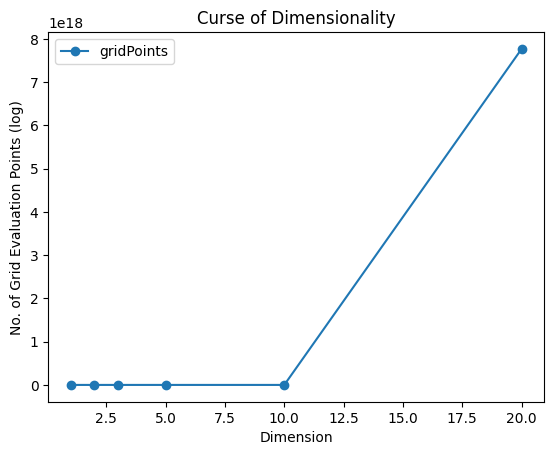

In [ ]:
resultsD.plot(x='D', marker='o')
plt.title('Curse of Dimensionality')
plt.ylabel('No. of Grid Evaluation Points (log)')
plt.xlabel('Dimension')
plt.show()

## II. Gradient Descent & Learning Rate Dynamics

1. Implement the Gradient Descent using the First-order Gradient Formula:$$w_{k+1} = w_k - \alpha \nabla g(w_{k})$$


To do this, we create a function to implement the Gradient Descent using the First-order gradient formula. The function `gradient_descent` has arguments: starting position `w0`, learning rate `a`, gradient lambda function `gradient`, number of max iterations `k`, and the gradient value threshold `e`.

In [ ]:
def gradient_descent(w0, a, function, gradient, k, e):
    """
    w0: starting position
    a: learning rate
    gradient: lamda function of the gradient
    k: no. of max iterations
    e: gradient value threshold
    """

    results = {     # stores the result
        'step': [],
        'w': [],
        'g(w)': []
    }

    wk = w0         # initialize first step
    counter = 0
    while counter <= k:                         # stopping condition 1 (iter)
        results['step'].append(counter)         # step counter
        results['w'].append(wk)                 # position
        results['g(w)'].append(function(wk))    # function value

        grad = gradient(wk)                     # calculates gradient
        wk = wk - a*grad                        # calculates new position
        counter+=1                              # increments counter
        if abs(grad) < e:                       # stopping condition 2 (small)
            break

    results = pd.DataFrame(results)
    return results

2. Test step sizes $\alpha \in \{ 0.05, 0.20, 1.20\}$ on $g(w) = w^2$ over 5 steps from $w^0 = 3.0$.

We first define our original function and its gradient through hard coding.
$$g(w) = w^2$$
$$\nabla g(w) = 2w$$

We then define our list of step sizes to iterate over it when using the previously defined function.

In [ ]:
func1 = lambda w: w**2          # Original Function
grad1 = lambda w: 2*w           # Gradient Function
step_sizes = [0.05, 0.20, 1.20]

# iterate over the step sizes
for step in step_sizes:
    trial = gradient_descent(w0=3.0,
                       a=step,
                       function=func1,
                       gradient=grad1,
                       k=5,
                       e=0.0000001)
    print(f"==== Results at a={step} ====\n", trial, "\n")

==== Results at a=0.05 ====
    step        w      g(w)
0     0  3.00000  9.000000
1     1  2.70000  7.290000
2     2  2.43000  5.904900
3     3  2.18700  4.782969
4     4  1.96830  3.874205
5     5  1.77147  3.138106 

==== Results at a=0.2 ====
    step        w      g(w)
0     0  3.00000  9.000000
1     1  1.80000  3.240000
2     2  1.08000  1.166400
3     3  0.64800  0.419904
4     4  0.38880  0.151165
5     5  0.23328  0.054420 

==== Results at a=1.2 ====
    step         w        g(w)
0     0   3.00000    9.000000
1     1  -4.20000   17.640000
2     2   5.88000   34.574400
3     3  -8.23200   67.765824
4     4  11.52480  132.821015
5     5 -16.13472  260.329189 



3. Run GD on $g(w)=\sin{(3w)} + 0.3w^2$ with $\alpha=0.05$ using the initial values $w^0 = 4.5$ and $w^0 = -1.5$

We define our functions through hard coding.
$$g(w)=\sin{(3w)} + 0.3 w^2 $$
$$\nabla g(w) = 3\cos{(3w)} + 0.6w $$

First, we call the `gradient_descent` function with starting position at `w0=4.5` at maximum 5 iterations and learning rate `a=0.05`. After which, we change the starting position to `w0=-1.5` while leaving the other arguments constant.

In [ ]:
func2 = lambda w: math.sin(3*w) + 0.3*(w**2)    # Original function
grad2 = lambda w: 3*(math.cos(3*w)) + 0.6*w     # Gradient function

# compute for w^0 at 4.5
trial1 = gradient_descent(w0=4.5,
                          a=0.05,
                          function=func2,
                          gradient=grad2,
                          k=5,
                          e=0.0000001)

# compute for w^0 at -1.5
trial2 = gradient_descent(w0=-1.5,
                          a=0.05,
                          function=func2,
                          gradient=grad2,
                          k=5,
                          e=0.0000001)

print("==== Results at w^0=4.5 ====\n", trial1, "\n")
print("==== Results at w^0=-1.5 ====\n", trial2, "\n")

==== Results at w^0=4.5 ====
    step         w      g(w)
0     0  4.500000  6.878784
1     1  4.275762  5.742607
2     2  4.002566  4.276099
3     3  3.755295  3.266984
4     4  3.602582  2.911166
5     5  3.522513  2.812646 

==== Results at w^0=-1.5 ====
    step         w      g(w)
0     0 -1.500000  1.652530
1     1 -1.423381  1.511596
2     2 -1.316483  1.242747
3     3 -1.173332  0.782449
4     4 -0.998743  0.154395
5     5 -0.820363 -0.427286 



## III. Bayesian LInear Regression

Implement the BayesianRidge work flow on synthetic house pricing. Set prior
precision control hyperparameters given in the sample source code in the
learning material. Extract point predictions (`mean_prediction`) and standard
deviations (`std_prediction`) for both interpolated and extrapolated values using `return_std=True`.

In [ ]:
from sklearn.linear_model import BayesianRidge

np.random.seed(42)

# Sample data (house square footage) with added noise to demonstrate uncertainty
X = np.array([[50], [100], [150], [200], [250]])

# Target values (house prices) with added random noise
y = (np.array([100000, 200000, 300000, 400000, 500000]) + np.random.normal(0, 30000, X.shape[0]))

# Create and fit the model with adjusted parameters to emphasize uncertainty
# alpha_1, alpha_2, lambda_1, lambda_2 control the prior distributions over precision of weights and noise
model = BayesianRidge(alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6)
model.fit(X, y)

# Predict the price and uncertainty for a new 120 m^2 house
new_house_sqft = np.array([[120]])
mean_prediction, std_prediction = model.predict(new_house_sqft, return_std=True)

print(f"Predicted price for 120 m^2: ${mean_prediction[0]:,.2f}")
print(f"Uncertainty (std dev) for 120 m^2: ${std_prediction[0]:,.2f}")

# Predict for an extrapolated value to show increased uncertainty (350 m^2)
extrapolated_sqft = np.array([[350]])
mean_extrapolated, std_extrapolated = model.predict(extrapolated_sqft, return_std=True)
print(f"Predicted price for 350 m^2 (extrapolated): ${mean_extrapolated[0]:,.2f}")
print(f"Uncertainty (std dev) for 350 m^2: ${std_extrapolated[0]:,.2f}")

Predicted price for 120 m^2: $253,679.60
Uncertainty (std dev) for 120 m^2: $26,625.02
Predicted price for 350 m^2 (extrapolated): $714,373.37
Uncertainty (std dev) for 350 m^2: $51,462.04


**Interpretation**

From the synthetic data of house areas and prices, the code above fits a BayesianRidge model to predict the house price given its area. As we can see in the sample prediction, the predicted price for a house of $120m^2$ is \$253,679.00. Unlike frequentist models, the BayesianRidge model outputs a distribution for the predicted price; hence, there is a standard deviation of $26,625.02.

As for predicting the price beyond what the model is trained on (extrapolated), it was able to predict the price of a $350 m^2$ house as \$714,373.37 with a standard deviation of $51,462.04.

## Zero-Order vs. First-Order Optimization Data Table

For the Zero-Order Optimization, we employ both Uniform Sampling and Random sampling to estimate the answer of function $$g(w) = w^2 + 0.2$$ at $N=25$.

For the First-Order Optimization, we employ the gradient descent formula at maximum iterations $k=5$, learning rate $a=0.20$, initial position $w_0 = 3$, and using the function $$g(w)=w^2$$ $$\nabla g(w) = 2w$$

In [ ]:
# Zero-Order Optimization at Uniform Sampling
unif = sampling(g, -1, 1, 25, uniform=True)
unif = pd.DataFrame(unif, columns=['x', 'y'])
print("=== Zero-Order Optimization at Uniform Sampling ===")
unif.sort_values(by='y').head()

=== Zero-Order Optimization at Uniform Sampling ===


,x,y
12,0.000000,0.200000
13,0.083333,0.206944
11,-0.083333,0.206944
14,0.166667,0.227778
10,-0.166667,0.227778


In [ ]:
# Zero-Order Optimization at Random Sampling
random_sampling = sampling(g, -1, 1, 25, uniform=False)
random_sampling = pd.DataFrame(random_sampling, columns=['x', 'y'])
print("=== Zero-Order Optimization at Random Sampling ===")
random_sampling.sort_values(by='y').head()

=== Zero-Order Optimization at Random Sampling ===


,x,y
14,0.028469,0.200810
15,0.049513,0.202452
13,-0.087860,0.207719
12,-0.136110,0.218526
16,0.184829,0.234162


In [ ]:
func3 = lambda w: w**2          # Original function
grad3 = lambda w: 2*w           # Gradient function

trial3 = gradient_descent(w0=3,
                          a=0.20,
                          function=func3,
                          gradient=grad3,
                          k=5,
                          e=0.0000001)
trial3

,step,w,g(w)
0,0,3.00000,9.000000
1,1,1.80000,3.240000
2,2,1.08000,1.166400
3,3,0.64800,0.419904
4,4,0.38880,0.151165
5,5,0.23328,0.054420


| Method | Dimension (D) | Evaluated Points (N) | best Minimum g(w) | Exact Global Minimum g(w) |
| --- | --- | --- | --- | --- |
| Uniform Grid Search | 1 | 4, 25 | 0.200000 | 0.2 |
| Random Sampling | 1 | 4, 25 | 0.200810| 0.2 |
| Gradient Descent (a=0.2) | 1 | 5 iterations | 0.054420 | 0 |